# Predicting House Prices Using Machine Learning (Ames Housing)

**Course:** D7054E Data Science Programming  
**Group:** 38  
**Members:** Avijit Saha, Seyed Morteza Salehi

---

## What this notebook tries to do (in simple words)

We are trying to predict **house sale prices** using the Kaggle *House Prices: Advanced Regression Techniques* dataset.

We follow a full data science pipeline:

1. **Load the data** (show data retrieval)
2. **Explore the data** (EDA + plots)
3. **Form/check hypotheses** (simple numeric checks)
4. **Clean + preprocess** (missing values + encoding)
5. **Feature engineering** (extra features so we go beyond a baseline)
6. **Train multiple models** and compare them with cross-validation
7. **Evaluate results** and make diagnostic plots
8. *(Optional)* create a `submission.csv`

> **Style note:** The comments are intentionally written in a student-like way, like we are explaining our thinking to ourselves and also to someone else reading it.


## 0) Imports and basic settings

We keep imports in one cell so it's easy to find.
Also we set a random seed so that results are reproducible (at least for models that use randomness).


In [1]:

# -----------------------------
# Core libraries (data handling)
# -----------------------------
from pathlib import Path

import numpy as np
import pandas as pd

# -----------------------------
# Plotting libraries
# -----------------------------
import matplotlib.pyplot as plt
import seaborn as sns

# -----------------------------
# Scikit-learn for ML pipeline
# -----------------------------
from sklearn.model_selection import KFold, cross_val_predict
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

# Models
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor

# Metrics
from sklearn.metrics import mean_squared_error, r2_score

# Make plots look consistent
sns.set_theme(style="whitegrid")

# If we change this, we should mention it in the report
RANDOM_STATE = 42


## 1) Data Retrieval (loading train/test CSV)

The assignment asks us to show how we retrieve data.
Here, we assume we already downloaded Kaggle files locally.

**Expected folder structure** (we keep it simple):

```
project/
  data/
    train.csv
    test.csv
  images/
  House_Prices_D7054E_Group38.ipynb
```

If you get a `FileNotFoundError`, it usually means the CSV files are not in the `data/` folder.


In [2]:

# -----------------------------
# Define project paths
# -----------------------------
ROOT_DIR = Path('.').resolve()
DATA_DIR = ROOT_DIR / 'data'
IMAGES_DIR = ROOT_DIR / 'images'

# Create images folder if it doesn't exist
IMAGES_DIR.mkdir(exist_ok=True)

TRAIN_PATH = DATA_DIR / 'train.csv'
TEST_PATH = DATA_DIR / 'test.csv'


def load_csv(path: Path) -> pd.DataFrame:
    """Load a CSV file into a DataFrame (with a friendly error message)."""
    if not path.exists():
        raise FileNotFoundError(
            f"File not found: {path}. "
            "Put train.csv and test.csv inside the data/ folder."
        )
    return pd.read_csv(path)


# Actually load the files
train_df = load_csv(TRAIN_PATH)
test_df = load_csv(TEST_PATH)

print('Train shape:', train_df.shape)
print('Test shape :', test_df.shape)

# Peek at the first rows to confirm it looks correct
train_df.head()


Train shape: (1460, 81)
Test shape : (1459, 80)


,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


## 2) Sanity checks (quick things before we go deeper)

We do quick checks to avoid silly mistakes:
- Is the target column `SalePrice` present?
- Any missing values in target?

If the target is missing, we cannot train properly.


In [3]:

TARGET_COL = 'SalePrice'

# Check target column existence
if TARGET_COL not in train_df.columns:
    raise ValueError(
        f"Target column '{TARGET_COL}' not found. "
        "Make sure you loaded the correct Kaggle train.csv file."
    )

print('✅ Target column exists:', TARGET_COL)
print('Missing target values:', train_df[TARGET_COL].isna().sum())


✅ Target column exists: SalePrice
Missing target values: 0


## 3) Exploratory Data Analysis (EDA)

EDA is where we try to *understand the dataset* before modeling.

We look at:
- Distribution of `SalePrice` (raw and log)
- Missing values (which columns have lots of missing)
- Correlations for numeric features

Why log-transform?
- SalePrice is usually right-skewed.
- Many models behave better when target looks more normal.

We also save plots into the `images/` folder.


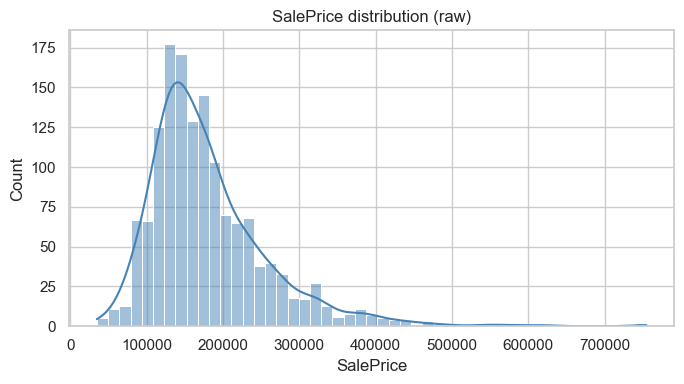

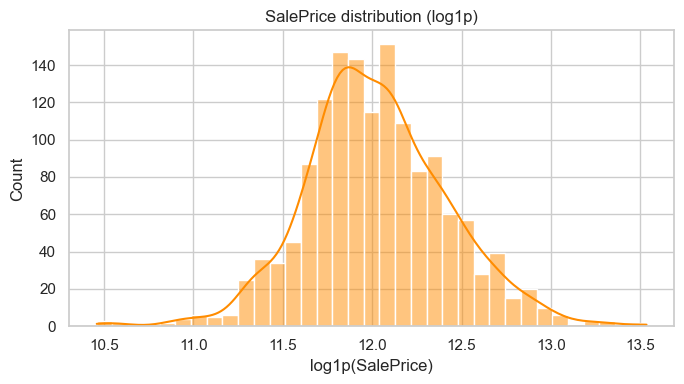

In [4]:

# -----------------------------
# 3.1 Target distribution (raw)
# -----------------------------
plt.figure(figsize=(7, 4))
sns.histplot(train_df[TARGET_COL], kde=True, color='steelblue')
plt.title('SalePrice distribution (raw)')
plt.xlabel(TARGET_COL)
plt.ylabel('Count')
plt.tight_layout()
plt.savefig(IMAGES_DIR / 'saleprice_raw.png', dpi=160)
plt.show()

# -----------------------------
# 3.2 Target distribution (log1p)
# -----------------------------
# Student note: log1p(x) = log(1 + x), and it avoids problems with log(0)
train_df['SalePrice_log'] = np.log1p(train_df[TARGET_COL])

plt.figure(figsize=(7, 4))
sns.histplot(train_df['SalePrice_log'], kde=True, color='darkorange')
plt.title('SalePrice distribution (log1p)')
plt.xlabel('log1p(SalePrice)')
plt.ylabel('Count')
plt.tight_layout()
plt.savefig(IMAGES_DIR / 'saleprice_log.png', dpi=160)
plt.show()


In [5]:

# -----------------------------
# 3.3 Missing values report
# -----------------------------
# We calculate how many missing values each column has
missing_count = train_df.isna().sum()
missing_pct = (missing_count / len(train_df)) * 100

missing_report = (
    pd.DataFrame({'missing_count': missing_count, 'missing_pct': missing_pct})
    .sort_values('missing_count', ascending=False)
)

# Show top 20 missing columns
missing_report.head(20)


,missing_count,missing_pct
PoolQC,1453,99.520548
MiscFeature,1406,96.301370
Alley,1369,93.767123
Fence,1179,80.753425
MasVnrType,872,59.726027
FireplaceQu,690,47.260274
LotFrontage,259,17.739726
GarageType,81,5.547945
GarageYrBlt,81,5.547945
GarageCond,81,5.547945


/var/folders/s1/h1strgd11s3_hmnzk90trm8w0000gn/T/ipykernel_58184/558409265.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=corr_top.values, y=corr_top.index, palette='viridis')


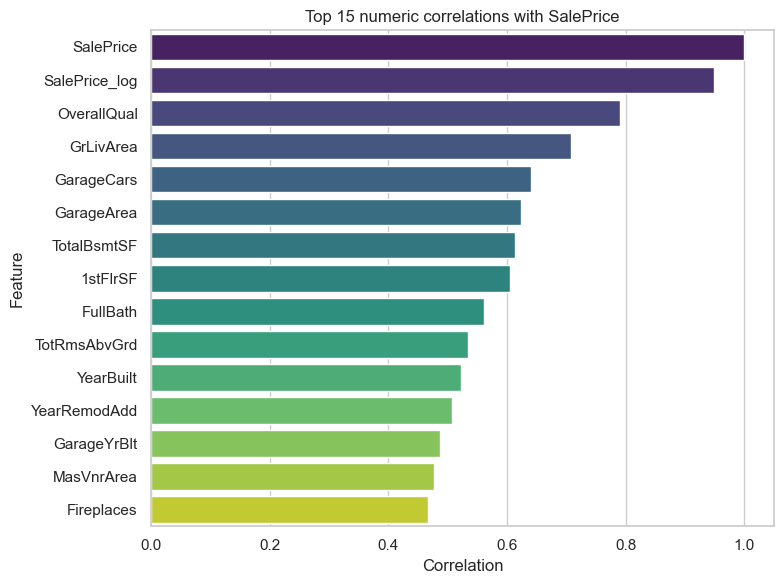

,correlation
SalePrice,1.000000
SalePrice_log,0.948374
OverallQual,0.790982
GrLivArea,0.708624
GarageCars,0.640409
GarageArea,0.623431
TotalBsmtSF,0.613581
1stFlrSF,0.605852
FullBath,0.560664
TotRmsAbvGrd,0.533723


In [6]:

# -----------------------------
# 3.4 Correlation with SalePrice (numeric only)
# -----------------------------
# Student note: correlation is not causation, but it's a quick signal.

numeric_df = train_df.select_dtypes(include=['number']).copy()
correlations = numeric_df.corr(numeric_only=True)[TARGET_COL].dropna()

# Top 15 by absolute correlation
corr_top = correlations.reindex(correlations.abs().sort_values(ascending=False).index).head(15)

plt.figure(figsize=(8, 6))
sns.barplot(x=corr_top.values, y=corr_top.index, palette='viridis')
plt.title('Top 15 numeric correlations with SalePrice')
plt.xlabel('Correlation')
plt.ylabel('Feature')
plt.tight_layout()
plt.savefig(IMAGES_DIR / 'top_correlations.png', dpi=160)
plt.show()

corr_top.to_frame('correlation')


## 4) Hypotheses (simple checks)

From our proposal, we had hypotheses like:

- **H1:** size features matter (example: `GrLivArea`)
- **H2:** quality features matter (example: `OverallQual`)
- **H3:** ensemble models should outperform linear models

Here we do simple numeric checks for H1 and H2 using correlation.
This is not a full statistical test (like t-test), but it is a clear, easy-to-explain check.


In [7]:

# We pick two classic features:
# - GrLivArea: above ground living area (size-related)
# - OverallQual: overall material and finish quality (quality-related)

cols_to_check = ['GrLivArea', 'OverallQual', TARGET_COL]

# Drop missing rows so correlation doesn't break
sub = train_df[cols_to_check].dropna()

corr_size = sub['GrLivArea'].corr(sub[TARGET_COL])
corr_quality = sub['OverallQual'].corr(sub[TARGET_COL])

print(f"Corr(GrLivArea, SalePrice)   = {corr_size:.3f}")
print(f"Corr(OverallQual, SalePrice) = {corr_quality:.3f}")

# Student interpretation:
# If both are positive and reasonably large, it supports H1 and H2.


Corr(GrLivArea, SalePrice)   = 0.709
Corr(OverallQual, SalePrice) = 0.791


## 5) Feature Engineering (so we go beyond a baseline)

The instructor feedback said to not be too close to a common baseline.
So we add a couple of simple but meaningful engineered features:

- `HouseAge = YrSold - YearBuilt`
- `TotalSF = TotalBsmtSF + 1stFlrSF + 2ndFlrSF`

Why these?
- Age is often related to price (but it can be non-linear, renovations matter etc.)
- Total square footage is a strong overall measure of size

We keep feature engineering *explainable*, because in the oral exam we must justify it.


In [8]:


def add_engineered_features(df: pd.DataFrame) -> pd.DataFrame:
    """Add engineered features. We return a copy to avoid side effects."""
    df = df.copy()

    # 5.1 HouseAge
    # Student note: We clip negative ages to 0 just in case of odd values.
    if 'YrSold' in df.columns and 'YearBuilt' in df.columns:
        df['HouseAge'] = (df['YrSold'] - df['YearBuilt']).clip(lower=0)

    # 5.2 TotalSF
    # Student note: Some houses may have missing basement areas.
    # We fill missing with 0 so sum doesn't become NaN.
    sf_cols = ['TotalBsmtSF', '1stFlrSF', '2ndFlrSF']
    if all(col in df.columns for col in sf_cols):
        df['TotalSF'] = df[sf_cols].fillna(0).sum(axis=1)

    return df


train_fe = add_engineered_features(train_df)
test_fe = add_engineered_features(test_df)

print('New columns added:', sorted(set(train_fe.columns) - set(train_df.columns)))
train_fe[['HouseAge', 'TotalSF']].head()


New columns added: ['HouseAge', 'TotalSF']


,HouseAge,TotalSF
0,5,2566
1,31,2524
2,7,2706
3,91,2473
4,8,3343


## 6) Preprocessing (cleaning + encoding)

This dataset has a mix of numeric and categorical features.

We need preprocessing because:
- Many columns have missing values
- Categorical columns must be converted into numbers

We use a scikit-learn `ColumnTransformer` pipeline:

**Numeric pipeline:**
- median imputation (simple and robust)
- standard scaling (helps linear models)

**Categorical pipeline:**
- most-frequent imputation
- one-hot encoding

> Student note: Doing preprocessing inside the pipeline helps avoid leakage in CV.


In [9]:

# Split features and target
X = train_fe.drop(columns=[TARGET_COL, 'SalePrice_log'], errors='ignore')

# We train on log target (helps with skew)
y = np.log1p(train_fe[TARGET_COL].values)

print(train_fe.columns)

# Identify column types
numeric_cols = X.select_dtypes(include=['number']).columns.tolist()
categorical_cols = X.select_dtypes(exclude=['number']).columns.tolist()

print('Numeric columns     :', len(numeric_cols))
print('Categorical columns :', len(categorical_cols))

# Numeric processing steps
numeric_pipe = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

# Categorical processing steps
categorical_pipe = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])

# Combine into one preprocessing transformer
preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_pipe, numeric_cols),
        ('cat', categorical_pipe, categorical_cols)
    ],
    remainder='drop'
)

print(X.columns.tolist())
print(train_fe.columns.tolist())


Index(['Id', 'MSSubClass', 'MSZoning', 'LotFrontage', 'LotArea', 'Street',
       'Alley', 'LotShape', 'LandContour', 'Utilities', 'LotConfig',
       'LandSlope', 'Neighborhood', 'Condition1', 'Condition2', 'BldgType',
       'HouseStyle', 'OverallQual', 'OverallCond', 'YearBuilt', 'YearRemodAdd',
       'RoofStyle', 'RoofMatl', 'Exterior1st', 'Exterior2nd', 'MasVnrType',
       'MasVnrArea', 'ExterQual', 'ExterCond', 'Foundation', 'BsmtQual',
       'BsmtCond', 'BsmtExposure', 'BsmtFinType1', 'BsmtFinSF1',
       'BsmtFinType2', 'BsmtFinSF2', 'BsmtUnfSF', 'TotalBsmtSF', 'Heating',
       'HeatingQC', 'CentralAir', 'Electrical', '1stFlrSF', '2ndFlrSF',
       'LowQualFinSF', 'GrLivArea', 'BsmtFullBath', 'BsmtHalfBath', 'FullBath',
       'HalfBath', 'BedroomAbvGr', 'KitchenAbvGr', 'KitchenQual',
       'TotRmsAbvGrd', 'Functional', 'Fireplaces', 'FireplaceQu', 'GarageType',
       'GarageYrBlt', 'GarageFinish', 'GarageCars', 'GarageArea', 'GarageQual',
       'GarageCond', 'PavedDrive

## 7) Model training + comparison (cross-validation)

We compare models from our proposal:

- LinearRegression (baseline)
- Ridge / Lasso (regularized linear models)
- RandomForest (ensemble of decision trees)
- GradientBoosting (boosting ensemble)

Why cross-validation?
- We don't want to trust a single train-test split
- CV gives us a more stable estimate of performance

We compute:
- RMSE (lower is better)
- R² (closer to 1 is better)

All evaluation is on the **log target**.


In [10]:


def rmse(y_true: np.ndarray, y_pred: np.ndarray) -> float:
    """Compute RMSE (root mean squared error)."""
    return float(np.sqrt(mean_squared_error(y_true, y_pred)))


models = {
    'LinearRegression': LinearRegression(),

    # Student note: Ridge/Lasso have alpha which controls regularization strength.
    'Ridge': Ridge(alpha=10.0, random_state=RANDOM_STATE),
    'Lasso': Lasso(alpha=0.001, random_state=RANDOM_STATE, max_iter=5000),

    # Student note: RandomForest and GradientBoosting can capture non-linear patterns.
    'RandomForest': RandomForestRegressor(
        n_estimators=300,
        random_state=RANDOM_STATE,
        n_jobs=-1
    ),
    'GradientBoosting': GradientBoostingRegressor(random_state=RANDOM_STATE)
}

# CV setup
cv = KFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

results = []

for name, model in models.items():
    # Build full pipeline = preprocessing + model
    pipe = Pipeline(steps=[
        ('preprocess', preprocessor),
        ('model', model)
    ])

    # Out-of-fold predictions (each sample predicted by a model that didn't train on it)
    y_pred = cross_val_predict(pipe, X, y, cv=cv, n_jobs=-1)

    results.append({
        'model': name,
        'rmse_log': rmse(y, y_pred),
        'r2_log': float(r2_score(y, y_pred))
    })

results_df = pd.DataFrame(results).sort_values(by='rmse_log')
results_df


,model,rmse_log,r2_log
4,GradientBoosting,0.134502,0.886542
3,RandomForest,0.144478,0.869089
2,Lasso,0.150495,0.857958
1,Ridge,0.152051,0.855004
0,LinearRegression,0.159914,0.839622


## 8) Best model diagnostics (plots)

After comparing models, we pick the best one (lowest RMSE).
Then we create two diagnostic plots:

1. Predicted vs Actual (should be close to a diagonal line)
2. Residuals vs Predicted (we want residuals scattered around 0)

These plots are helpful to explain model behavior in the oral exam.


Best model based on RMSE: GradientBoosting


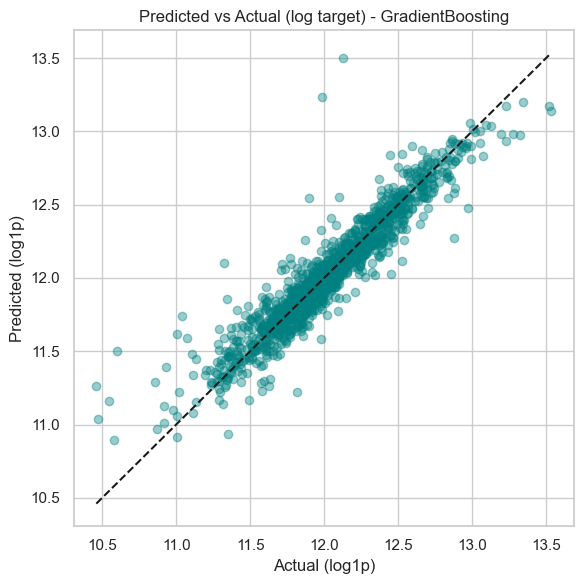

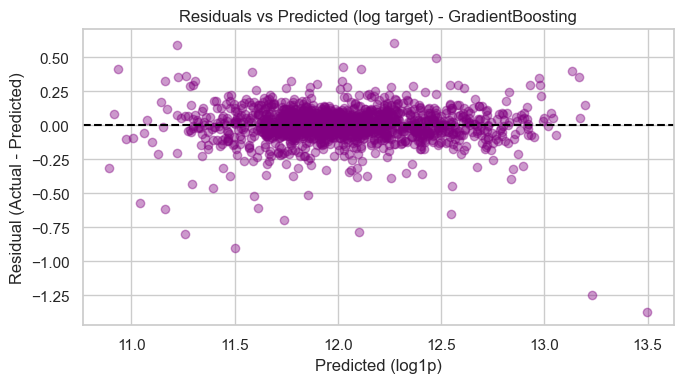

Saved plots in: /Users/morteza/Downloads/Git/LTU-DSP-Project/images


In [11]:

# Pick best model based on RMSE
best_model_name = results_df.iloc[0]['model']
print('Best model based on RMSE:', best_model_name)

best_pipe = Pipeline(steps=[
    ('preprocess', preprocessor),
    ('model', models[best_model_name])
])

# Out-of-fold predictions for best model
best_pred = cross_val_predict(best_pipe, X, y, cv=cv, n_jobs=-1)

# 8.1 Predicted vs Actual
plt.figure(figsize=(6, 6))
plt.scatter(y, best_pred, alpha=0.4, color='teal')
min_v = min(y.min(), best_pred.min())
max_v = max(y.max(), best_pred.max())
plt.plot([min_v, max_v], [min_v, max_v], 'k--')
plt.title(f'Predicted vs Actual (log target) - {best_model_name}')
plt.xlabel('Actual (log1p)')
plt.ylabel('Predicted (log1p)')
plt.tight_layout()
plt.savefig(IMAGES_DIR / 'predicted_vs_actual.png', dpi=160)
plt.show()

# 8.2 Residuals plot
residuals = y - best_pred
plt.figure(figsize=(7, 4))
plt.scatter(best_pred, residuals, alpha=0.4, color='purple')
plt.axhline(0, color='black', linestyle='--')
plt.title(f'Residuals vs Predicted (log target) - {best_model_name}')
plt.xlabel('Predicted (log1p)')
plt.ylabel('Residual (Actual - Predicted)')
plt.tight_layout()
plt.savefig(IMAGES_DIR / 'residuals.png', dpi=160)
plt.show()

print('Saved plots in:', IMAGES_DIR)


## 9) Train final model and predict test (optional Kaggle submission)

This is optional for the course, but useful if we want a Kaggle submission.

Steps:
1. Fit the best pipeline on **all training data**
2. Predict on test data
3. Convert predictions back to normal price scale (`expm1`)
4. Save `submission.csv`

Student note: Kaggle expects `Id` and `SalePrice` columns.


In [ ]:
# Fit best model on full training data
best_pipe.fit(X, y)

# Prepare test features
X_test = test_fe.copy()

# Predict log-prices then convert back to price scale
pred_test_log = best_pipe.predict(X_test)
pred_test_price = np.expm1(pred_test_log)

submission = pd.DataFrame({
    'Id': test_df['Id'],
    'SalePrice': pred_test_price
})

out_path = ROOT_DIR / 'submission.csv'
submission.to_csv(out_path, index=False)

print('Saved:', out_path)
submission.head()


Index(['Id', 'MSSubClass', 'MSZoning', 'LotFrontage', 'LotArea', 'Street',
       'Alley', 'LotShape', 'LandContour', 'Utilities', 'LotConfig',
       'LandSlope', 'Neighborhood', 'Condition1', 'Condition2', 'BldgType',
       'HouseStyle', 'OverallQual', 'OverallCond', 'YearBuilt', 'YearRemodAdd',
       'RoofStyle', 'RoofMatl', 'Exterior1st', 'Exterior2nd', 'MasVnrType',
       'MasVnrArea', 'ExterQual', 'ExterCond', 'Foundation', 'BsmtQual',
       'BsmtCond', 'BsmtExposure', 'BsmtFinType1', 'BsmtFinSF1',
       'BsmtFinType2', 'BsmtFinSF2', 'BsmtUnfSF', 'TotalBsmtSF', 'Heating',
       'HeatingQC', 'CentralAir', 'Electrical', '1stFlrSF', '2ndFlrSF',
       'LowQualFinSF', 'GrLivArea', 'BsmtFullBath', 'BsmtHalfBath', 'FullBath',
       'HalfBath', 'BedroomAbvGr', 'KitchenAbvGr', 'KitchenQual',
       'TotRmsAbvGrd', 'Functional', 'Fireplaces', 'FireplaceQu', 'GarageType',
       'GarageYrBlt', 'GarageFinish', 'GarageCars', 'GarageArea', 'GarageQual',
       'GarageCond', 'PavedDrive

,Id,SalePrice
0,1461,122276.758028
1,1462,162616.397781
2,1463,186052.101359
3,1464,194087.067972
4,1465,190475.280520


## 10) Ethics notes (short reflection)

We include ethics reflection because it is explicitly required.

- House prices can reflect historical inequalities.
- Location can act as a proxy for socio-economic status.
- If used in real life, we should monitor the model and avoid discriminatory use.

Student note: In the report, we can expand this into a more structured ethics section.
